C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3416357682.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3416357682.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .asfreq("H", fill_value=0)


Seasonality test for hourly EV charging load
Start: 2018-01-01 17:00:00
End  : 2023-11-30 23:00:00
Total samples: 51823

ACF check
Lag 24  : 0.475
Lag 168 : 0.5022
95% bound: 0.00861



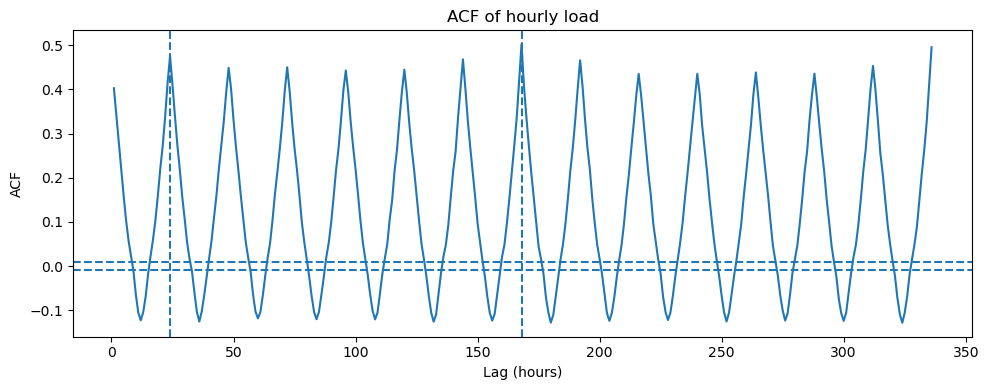

Periodogram check
Peak near 24 hours : (np.float64(0.04166103853501341), np.float64(24.0032422417786), np.float64(9799879.753256802))
Peak near 168 hours: (np.float64(0.00598189992860313), np.float64(167.17096774193547), np.float64(54478.13616258169))



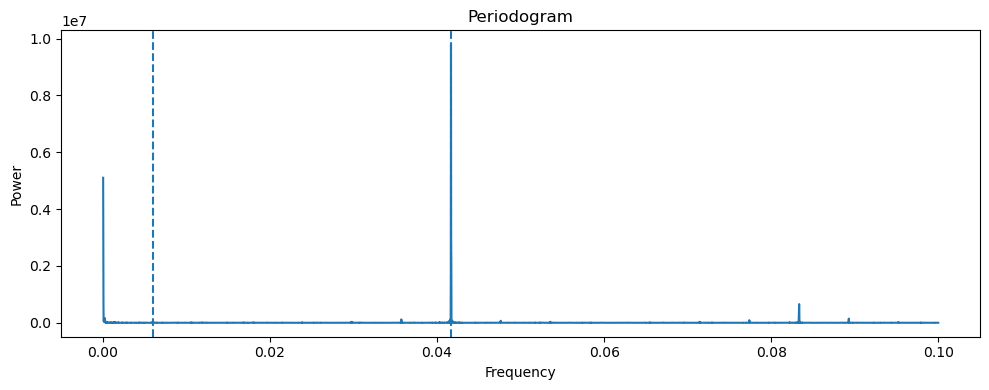

STL seasonal strength
Daily (24-hour): 0.384



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3416357682.py:123: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  plt.plot(daily_stl.seasonal.last("14D"))


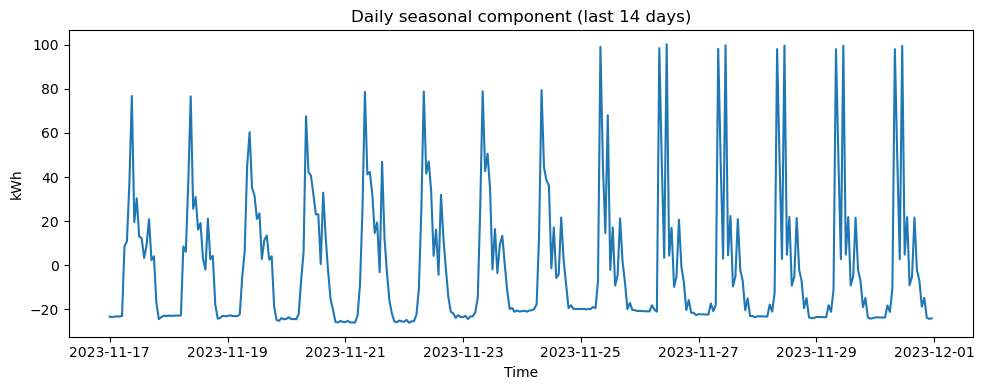

Weekly (7-day on daily totals): 0.259



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23536\3416357682.py:138: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  plt.plot(weekly_stl.seasonal.last("35D"))


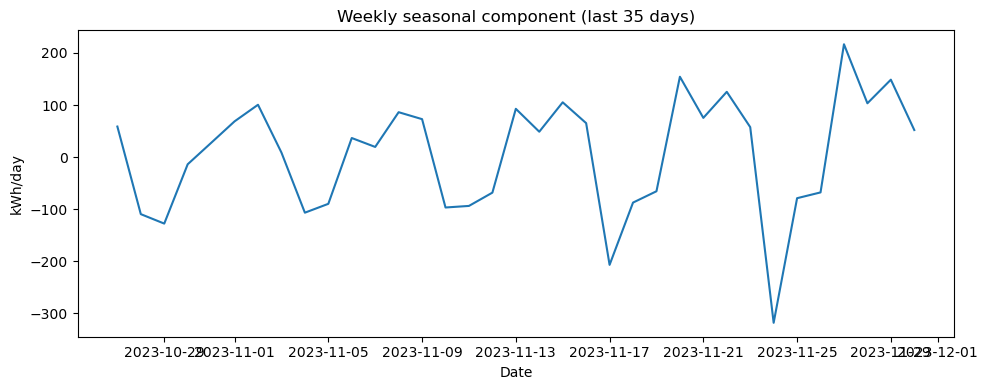

Final result
Threshold: 0.043049
Lag 24 seasonal : Yes
Lag 168 seasonal: Yes

Verdict: The dataset is seasonal.
Suggested SARIMA seasonal period: s = 24
There is also weekly seasonality at lag 168.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
from scipy.signal import periodogram


file_path = "Electric_Vehicle_Charging_Station_Data.csv"
time_col = "Start_Date___Time"
energy_col = "Energy__kWh_"

data = pd.read_csv(file_path)

data[time_col] = pd.to_datetime(data[time_col], errors="coerce")
data[energy_col] = pd.to_numeric(data[energy_col], errors="coerce")
data = data.dropna(subset=[time_col, energy_col])

hourly = (
    data.set_index(time_col)[energy_col]
    .sort_index()
    .resample("H")
    .sum()
    .asfreq("H", fill_value=0)
)

print("Seasonality test for hourly EV charging load")
print("Start:", hourly.index.min())
print("End  :", hourly.index.max())
print("Total samples:", len(hourly))
print()

y = hourly.values.astype(float)
n = len(y)
limit = 1.96 / np.sqrt(n)

max_lag = 24 * 14
acf_values = acf(y, nlags=max_lag, fft=True)
lags = np.arange(len(acf_values))

acf_24 = acf_values[24] if len(acf_values) > 24 else np.nan
acf_168 = acf_values[168] if len(acf_values) > 168 else np.nan

print("ACF check")
print("Lag 24  :", round(acf_24, 4))
print("Lag 168 :", round(acf_168, 4))
print("95% bound:", round(limit, 6))
print()

plt.figure(figsize=(10, 4))
plt.plot(lags[1:], acf_values[1:])
plt.axhline(limit, linestyle="--")
plt.axhline(-limit, linestyle="--")
plt.axvline(24, linestyle="--")
plt.axvline(168, linestyle="--")
plt.title("ACF of hourly load")
plt.xlabel("Lag (hours)")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

y_centered = y - y.mean()
freqs, power = periodogram(y_centered, fs=1.0)

freqs = freqs[1:]
power = power[1:]

def find_peak(target_period, tolerance=0.1):
    target_freq = 1 / target_period
    mask = (freqs >= target_freq * (1 - tolerance)) & (freqs <= target_freq * (1 + tolerance))

    if not np.any(mask):
        return None

    local_freqs = freqs[mask]
    local_power = power[mask]
    peak_index = np.argmax(local_power)

    peak_freq = local_freqs[peak_index]
    peak_period = 1 / peak_freq
    peak_power = local_power[peak_index]

    return peak_freq, peak_period, peak_power

daily_peak = find_peak(24, tolerance=0.05)
weekly_peak = find_peak(168, tolerance=0.10)

print("Periodogram check")
print("Peak near 24 hours :", daily_peak)
print("Peak near 168 hours:", weekly_peak)
print()

plt.figure(figsize=(10, 4))
mask = freqs <= 0.1
plt.plot(freqs[mask], power[mask])
plt.axvline(1 / 24, linestyle="--")
plt.axvline(1 / 168, linestyle="--")
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.tight_layout()
plt.show()

def get_seasonal_strength(result):
    seasonal = result.seasonal
    resid = result.resid
    denom = np.var(resid + seasonal)

    if denom == 0:
        return 0

    return 1 - (np.var(resid) / denom)

daily_stl = STL(hourly, period=24, robust=True).fit()
daily_strength = get_seasonal_strength(daily_stl)

print("STL seasonal strength")
print("Daily (24-hour):", round(daily_strength, 3))
print()

plt.figure(figsize=(10, 4))
plt.plot(daily_stl.seasonal.last("14D"))
plt.title("Daily seasonal component (last 14 days)")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.tight_layout()
plt.show()

daily_total = hourly.resample("D").sum()
weekly_stl = STL(daily_total, period=7, robust=True).fit()
weekly_strength = get_seasonal_strength(weekly_stl)

print("Weekly (7-day on daily totals):", round(weekly_strength, 3))
print()

plt.figure(figsize=(10, 4))
plt.plot(weekly_stl.seasonal.last("35D"))
plt.title("Weekly seasonal component (last 35 days)")
plt.xlabel("Date")
plt.ylabel("kWh/day")
plt.tight_layout()
plt.show()

k = 5
daily_seasonal = abs(acf_24) > k * limit if np.isfinite(acf_24) else False
weekly_seasonal = abs(acf_168) > k * limit if np.isfinite(acf_168) else False

is_seasonal = daily_seasonal or weekly_seasonal

print("Final result")
print("Threshold:", round(k * limit, 6))
print("Lag 24 seasonal :", "Yes" if daily_seasonal else "No")
print("Lag 168 seasonal:", "Yes" if weekly_seasonal else "No")
print()

if is_seasonal:
    print("Verdict: The dataset is seasonal.")
    print("Suggested SARIMA seasonal period: s = 24")
    if weekly_seasonal:
        print("There is also weekly seasonality at lag 168.")
else:
    print("Verdict: The dataset is not strongly seasonal.")